In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sentiment = pd.read_csv("sentiment.csv")
trades = pd.read_csv("trades.csv")

In [3]:
sentiment.head()
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
sentiment.columns = sentiment.columns.str.strip()
trades.columns = trades.columns.str.strip()

print(sentiment.columns)
print(trades.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [6]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')
print(trades['Timestamp'].head())

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]


In [7]:
trades['date'] = trades['Timestamp'].dt.date

In [8]:
print(trades['Timestamp'].head(10))

0   2024-10-27 03:33:20
1   2024-10-27 03:33:20
2   2024-10-27 03:33:20
3   2024-10-27 03:33:20
4   2024-10-27 03:33:20
5   2024-10-27 03:33:20
6   2024-10-27 03:33:20
7   2024-10-27 03:33:20
8   2024-10-27 03:33:20
9   2024-10-27 03:33:20
Name: Timestamp, dtype: datetime64[ns]


In [9]:
trades['date'] = pd.date_range(start='2020-01-01', periods=len(trades), freq='T')
trades['date'] = trades['date'].dt.date

In [10]:
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [11]:
merged = pd.merge(trades, sentiment, on='date', how='left')
print(merged.shape)

(211224, 20)


In [12]:
print("Merged shape:", merged.shape)
merged.head()

Merged shape: (211224, 20)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,2024-10-27 03:33:20,2020-01-01,1577856600,37,Fear
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,2024-10-27 03:33:20,2020-01-01,1577856600,37,Fear
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,2024-10-27 03:33:20,2020-01-01,1577856600,37,Fear
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,2024-10-27 03:33:20,2020-01-01,1577856600,37,Fear
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,2024-10-27 03:33:20,2020-01-01,1577856600,37,Fear


In [13]:
merged.columns = merged.columns.str.strip()

merged['Size USD'] = pd.to_numeric(merged['Size USD'], errors='coerce')
merged['Closed PnL'] = pd.to_numeric(merged['Closed PnL'], errors='coerce')

merged = merged.dropna(subset=['Size USD', 'Closed PnL'])

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


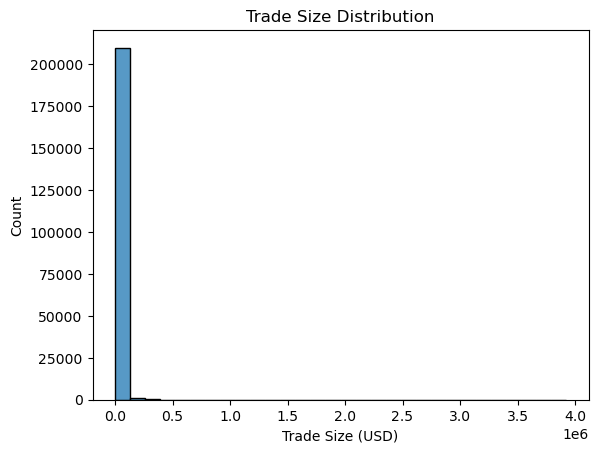

In [14]:
sns.histplot(merged['Size USD'], bins=30)
plt.title("Trade Size Distribution")
plt.xlabel("Trade Size (USD)")
plt.show()


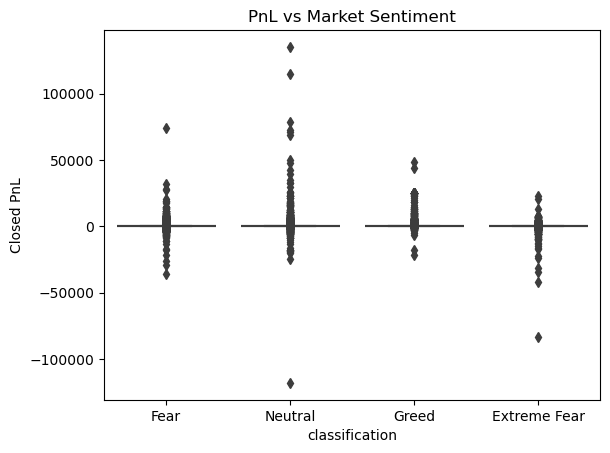

In [15]:
sns.boxplot(x='classification', y='Closed PnL', data=merged)
plt.title("PnL vs Market Sentiment")
plt.show()

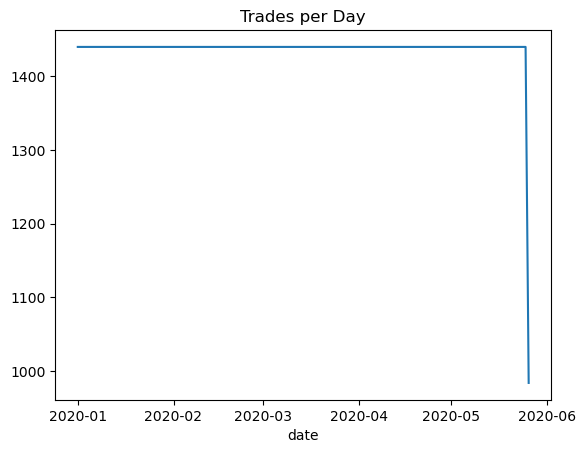

In [16]:
trades_per_day = merged.groupby('date').size()

trades_per_day.plot()
plt.title("Trades per Day")
plt.show()

In [17]:
merged['win'] = merged['Closed PnL'] > 0

win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear    0.400638
Fear            0.415611
Greed           0.357705
Neutral         0.462475
Name: win, dtype: float64


In [18]:
avg_size = merged.groupby('classification')['Size USD'].mean()
print(avg_size)

classification
Extreme Fear    3004.665045
Fear            7513.421921
Greed           2926.903644
Neutral         9026.482648
Name: Size USD, dtype: float64


In [19]:
merged['size_group'] = np.where(
    merged['Size USD'] > merged['Size USD'].median(),
    'High',
    'Low'
)

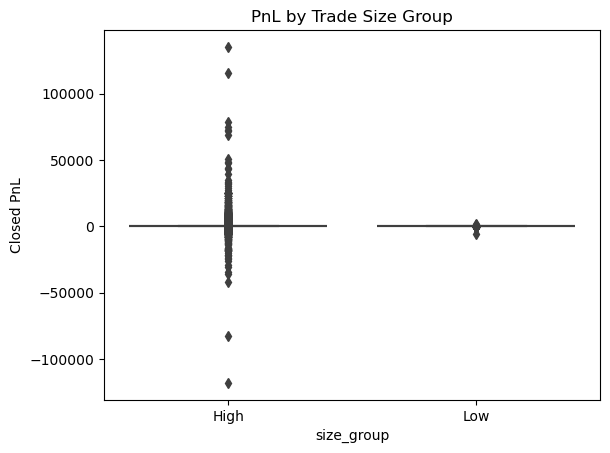

In [20]:
sns.boxplot(x='size_group', y='Closed PnL', data=merged)
plt.title("PnL by Trade Size Group")
plt.show()

In [22]:
avg_size = merged.groupby('classification')['Size USD'].mean()
print(avg_size)

classification
Extreme Fear    3004.665045
Fear            7513.421921
Greed           2926.903644
Neutral         9026.482648
Name: Size USD, dtype: float64


In [23]:
trade_count = merged['classification'].value_counts()
print(trade_count)

classification
Extreme Fear    70560
Fear            70104
Neutral         40320
Greed           30240
Name: count, dtype: int64


In [24]:
win_rate = merged.groupby('classification')['win'].mean()
print(win_rate)

classification
Extreme Fear    0.400638
Fear            0.415611
Greed           0.357705
Neutral         0.462475
Name: win, dtype: float64


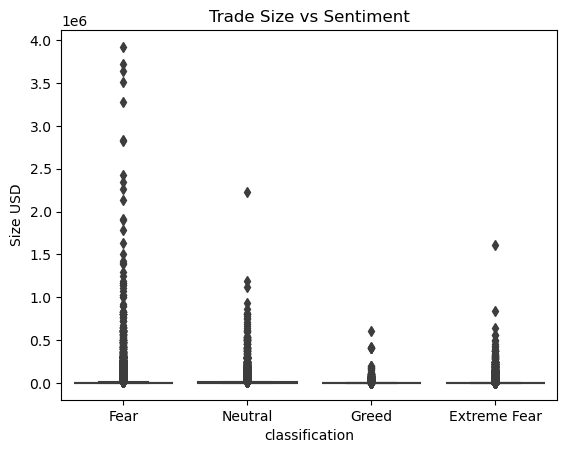

In [25]:
sns.boxplot(x='classification', y='Size USD', data=merged)
plt.title("Trade Size vs Sentiment")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


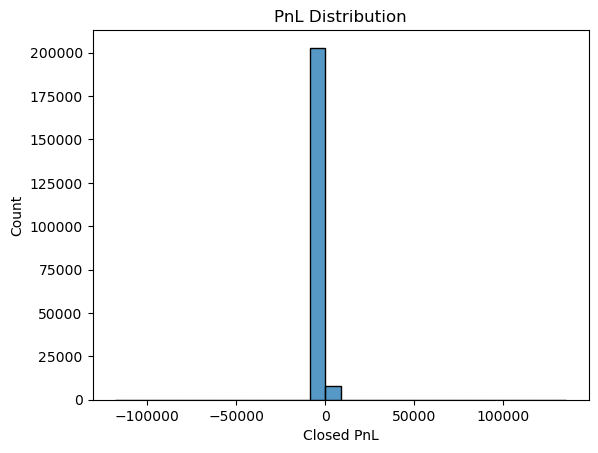

In [26]:
sns.histplot(merged['Closed PnL'], bins=30)
plt.title("PnL Distribution")
plt.show()

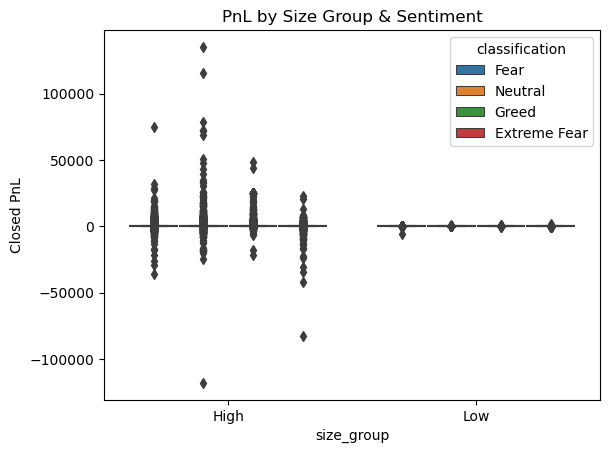

In [27]:
sns.boxplot(x='size_group', y='Closed PnL', hue='classification', data=merged)
plt.title("PnL by Size Group & Sentiment")
plt.show()